In [3]:
import os
import multiprocessing

def configure_threading(max_threads=None):
    """Set thread env variables so numeric libs leverage multiple CPU cores."""
    if max_threads is None:
        max_threads = multiprocessing.cpu_count()
    thread_env_vars = [
        "OMP_NUM_THREADS",
        "OPENBLAS_NUM_THREADS",
        "MKL_NUM_THREADS",
        "VECLIB_MAXIMUM_THREADS",
        "NUMEXPR_NUM_THREADS",
    ]
    for var in thread_env_vars:
        os.environ[var] = str(max_threads)
    print(f"Threading configured to use up to {max_threads} CPU cores.")

configure_threading()

Threading configured to use up to 12 CPU cores.


In [4]:
# Import required libraries
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, box
from shapely.ops import unary_union

# Set plotting style using seaborn
sns.set_theme(style='darkgrid', palette='husl')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


---
## Section 1: Data Loading & Polygon Conversion

In [5]:
# Load the shapefiles
print("="*70)
print("LOADING DATASETS")
print("="*70)

algeria_lc = gpd.read_file('../dataset/land_cover_dataset/algeria/dza_gc_adg.shp')
tunisia_lc_points = gpd.read_file('../dataset/land_cover_dataset/tunisia/Tunisia_LC_2022_point_data.shp')

# Rename land cover columns to a common name for consistency
algeria_lc = algeria_lc.rename(columns={'LCCCODE': 'landcover'})
tunisia_lc_points = tunisia_lc_points.rename(columns={'Class': 'landcover'})

# Harmonize CRS
if tunisia_lc_points.crs != algeria_lc.crs:
    tunisia_lc_points = tunisia_lc_points.to_crs(algeria_lc.crs)

print(f"\n✓ Algeria loaded: {len(algeria_lc):,} polygons")
print(f"  Geometry type: {algeria_lc.geom_type.unique().tolist()}")
print(f"\n✓ Tunisia loaded: {len(tunisia_lc_points):,} points")
print(f"  Geometry type: {tunisia_lc_points.geom_type.unique().tolist()}")
print("\n" + "="*70)

LOADING DATASETS

✓ Algeria loaded: 386,454 polygons
  Geometry type: ['Polygon']

✓ Tunisia loaded: 4,747 points
  Geometry type: ['Point']



In [6]:
# =====================================================
# Convert Tunisia Points to Voronoi Polygons
# =====================================================
print("="*70)
print("CONVERTING TUNISIA POINTS TO VORONOI POLYGONS")
print("="*70)

def points_to_voronoi_polygons(gdf_points):
    """
    Convert point geometries to Voronoi polygons.
    Each point becomes the centroid of a polygon region.
    
    Voronoi tessellation partitions space so that each polygon
    contains all locations closest to its seed point.
    Polygons are clipped to the convex hull of the points to avoid
    extending beyond the actual data extent.
    """
    print("\nStep 1: Extracting point coordinates...")
    coords = np.array([[geom.x, geom.y] for geom in gdf_points.geometry])
    print(f"  Extracted {len(coords)} coordinate pairs")
    
    # Get bounding box with buffer
    minx, miny, maxx, maxy = gdf_points.total_bounds
    buffer_x = (maxx - minx) * 0.1
    buffer_y = (maxy - miny) * 0.1
    print(f"\nStep 2: Bounding box calculated")
    print(f"  X range: [{minx:.4f}, {maxx:.4f}]")
    print(f"  Y range: [{miny:.4f}, {maxy:.4f}]")
    
    # Create convex hull of points for clipping (this represents Tunisia's shape)
    print("\nStep 3: Creating convex hull boundary for clipping...")
    all_points_union = gdf_points.geometry.unary_union
    convex_hull = all_points_union.convex_hull
    # Add a small buffer to the convex hull to ensure edge points are included
    clip_boundary = convex_hull.buffer(0.05)
    print(f"  Convex hull created with {len(convex_hull.exterior.coords)} vertices")
    
    # Add boundary points to ensure finite Voronoi regions
    print("\nStep 4: Adding boundary points for finite regions...")
    boundary_points = np.array([
        [minx - buffer_x * 10, miny - buffer_y * 10],
        [maxx + buffer_x * 10, miny - buffer_y * 10],
        [minx - buffer_x * 10, maxy + buffer_y * 10],
        [maxx + buffer_x * 10, maxy + buffer_y * 10],
    ])
    
    all_coords = np.vstack([coords, boundary_points])
    
    # Compute Voronoi tessellation
    print("\nStep 5: Computing Voronoi tessellation...")
    vor = Voronoi(all_coords)
    print(f"  Generated {len(vor.regions)} regions")
    
    # Extract polygons for original points (not boundary points)
    # Clip to convex hull instead of bounding box
    print("\nStep 6: Extracting and clipping polygons to convex hull...")
    polygons = []
    fallback_count = 0
    
    for i in range(len(coords)):
        region_idx = vor.point_region[i]
        region = vor.regions[region_idx]
        
        if -1 in region or len(region) == 0:
            # Infinite or empty region - use a small buffer around the point
            buffered_point = gdf_points.geometry.iloc[i].buffer(0.01)
            clipped = buffered_point.intersection(clip_boundary)
            polygons.append(clipped if not clipped.is_empty else buffered_point)
            fallback_count += 1
        else:
            try:
                polygon = Polygon([vor.vertices[v] for v in region])
                # Clip to convex hull boundary (Tunisia's shape)
                polygon = polygon.intersection(clip_boundary)
                if polygon.is_empty or not polygon.is_valid:
                    polygon = gdf_points.geometry.iloc[i].buffer(0.01)
                    fallback_count += 1
                polygons.append(polygon)
            except Exception:
                polygons.append(gdf_points.geometry.iloc[i].buffer(0.01))
                fallback_count += 1
    
    print(f"  Created {len(polygons)} polygons")
    if fallback_count > 0:
        print(f"  (Used buffer fallback for {fallback_count} edge cases)")
    
    # Create new GeoDataFrame with polygons
    gdf_polygons = gdf_points.copy()
    gdf_polygons['geometry'] = polygons
    
    return gdf_polygons

# Convert Tunisia points to Voronoi polygons
tunisia_lc = points_to_voronoi_polygons(tunisia_lc_points)

# Validate and fix any invalid geometries
print("\nStep 7: Validating geometries...")
invalid_count = (~tunisia_lc.geometry.is_valid).sum()
if invalid_count > 0:
    print(f"  Fixing {invalid_count} invalid geometries...")
    tunisia_lc['geometry'] = tunisia_lc.geometry.buffer(0)
else:
    print("  All geometries are valid")

print("\n" + "="*70)
print("CONVERSION COMPLETE")
print("="*70)
print(f"\nOriginal Tunisia: {len(tunisia_lc_points):,} points")
print(f"Converted Tunisia: {len(tunisia_lc):,} polygons")
print(f"\nGeometry types:")
print(f"  Algeria: {algeria_lc.geom_type.unique().tolist()}")
print(f"  Tunisia: {tunisia_lc.geom_type.unique().tolist()}")
print("\n✓ Both datasets now have polygon geometries!")

CONVERTING TUNISIA POINTS TO VORONOI POLYGONS

Step 1: Extracting point coordinates...
  Extracted 4747 coordinate pairs

Step 2: Bounding box calculated
  X range: [7.5829, 11.5442]
  Y range: [30.2880, 37.3361]

Step 3: Creating convex hull boundary for clipping...
  Convex hull created with 21 vertices

Step 4: Adding boundary points for finite regions...

Step 5: Computing Voronoi tessellation...
  Generated 4744 regions

Step 6: Extracting and clipping polygons to convex hull...


C:\Users\mehdi\AppData\Local\Temp\ipykernel_4724\16746154.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  all_points_union = gdf_points.geometry.unary_union


  Created 4747 polygons

Step 7: Validating geometries...
  All geometries are valid

CONVERSION COMPLETE

Original Tunisia: 4,747 points
Converted Tunisia: 4,747 polygons

Geometry types:
  Algeria: ['Polygon']
  Tunisia: ['Polygon']

✓ Both datasets now have polygon geometries!


In [5]:
print("="*70)
print("DATASET STRUCTURE ANALYSIS")
print("="*70)

# Algeria Dataset Analysis
print("\n" + "="*70)
print("ALGERIA LAND COVER DATASET")
print("="*70)
print(f"\nShape: {algeria_lc.shape}")
print(f"Columns: {algeria_lc.columns.tolist()}")
print(f"CRS: {algeria_lc.crs}")
print(f"Geometry Type: {algeria_lc.geom_type.unique().tolist()}")
print(f"\nData Types:")
print(algeria_lc.dtypes)
print(f"\nFirst 5 rows:")
print(algeria_lc.head())

# Tunisia Dataset Analysis
print("\n" + "="*70)
print("TUNISIA LAND COVER DATASET (POLYGONS)")
print("="*70)
print(f"\nShape: {tunisia_lc.shape}")
print(f"Columns: {tunisia_lc.columns.tolist()}")
print(f"CRS: {tunisia_lc.crs}")
print(f"Geometry Type: {tunisia_lc.geom_type.unique().tolist()}")
print(f"\nData Types:")
print(tunisia_lc.dtypes)
print(f"\nFirst 5 rows:")
print(tunisia_lc.head())

print("\n" + "="*70)
print("✓ Dataset structure analysis complete!")
print("="*70)

DATASET STRUCTURE ANALYSIS

ALGERIA LAND COVER DATASET

Shape: (386454, 5)
Columns: ['ID', 'GRIDCODE', 'AREA', 'landcover', 'geometry']
CRS: EPSG:4326
Geometry Type: ['Polygon']

Data Types:
ID              int32
GRIDCODE        int32
AREA          float64
landcover      object
geometry     geometry
dtype: object

First 5 rows:
   ID  GRIDCODE          AREA     landcover  \
0   4       210  6.228187e+06  7001 // 8001   
1   2       210  6.242408e+06  7001 // 8001   
2   1       210  1.482995e+06  7001 // 8001   
3   8        50  4.590841e+08  21497-121340   
4  13       210  6.371533e+06  7001 // 8001   

                                            geometry  
0  POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...  
1  POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...  
2  POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...  
3  POLYGON ((6.12361 36.68472, 6.12361 36.69306, ...  
4  POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...  

TUNISIA LAND COVER DATASET (POLYGONS)

Shape: (4747, 5)


---
## Section 2: Exploratory Data Analysis

### 2.1 Univariate Analysis

UNIVARIATE ANALYSIS - LAND COVER DISTRIBUTION

--- Algeria Land Cover Distribution ---
landcover
0011                                168143
6001                                 57050
20049 // 20058                       39532
6004                                 25243
0003 / 0004                          23115
0004 // 0003                         18023
20058                                15922
21446 // 21450-121340 / 21454        11903
11498                                11155
21450                                 7313
21518                                 5127
21497-121340                          2099
21499-121340                           770
21454 // 21446 // 21450                392
7001 // 8001                           288
11490 // 11494                         228
0010                                    86
21497-15045                             48
21496-121340 // 21497-129401             8
6020                                     5
41638-60686-R2 // 41898-60686-R2         3


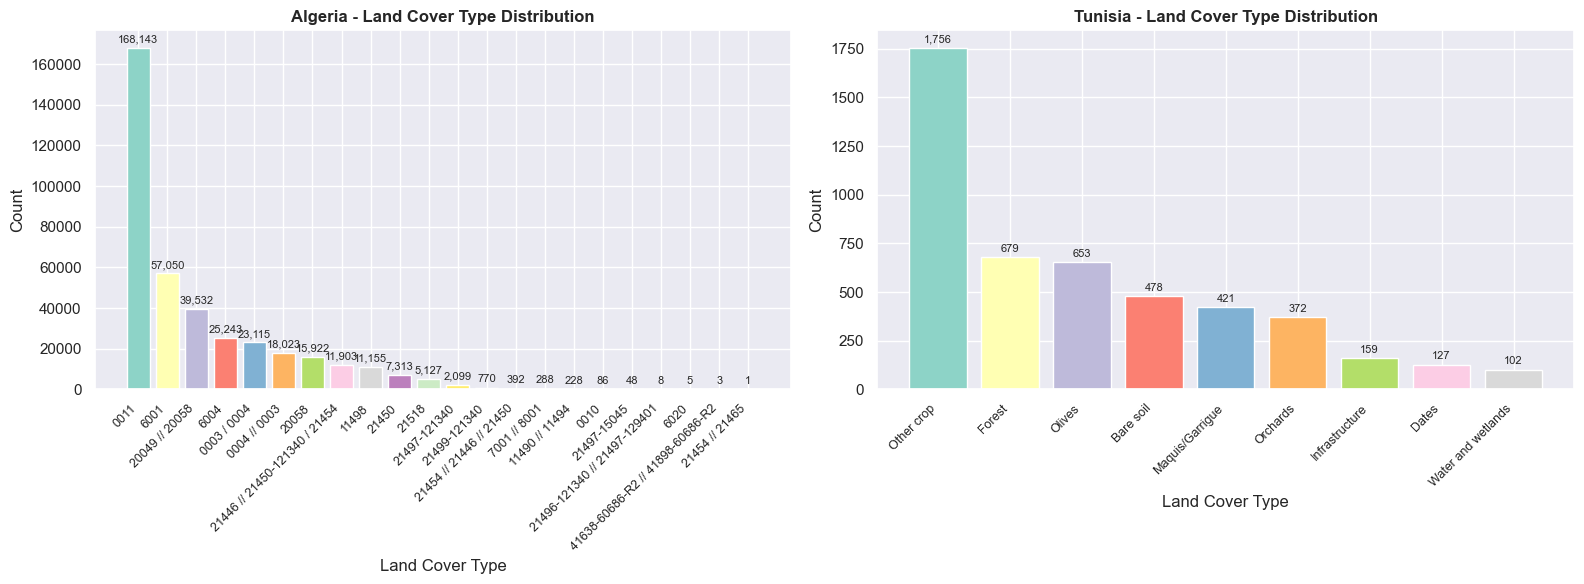


✓ Univariate analysis complete!


In [6]:
print("="*70)
print("UNIVARIATE ANALYSIS - LAND COVER DISTRIBUTION")
print("="*70)

# Algeria Land Cover Distribution
print("\n--- Algeria Land Cover Distribution ---")
algeria_lc_counts = algeria_lc['landcover'].value_counts()
print(algeria_lc_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Algeria bar plot
ax1 = axes[0]
colors_algeria = plt.cm.Set3(range(len(algeria_lc_counts)))
bars1 = ax1.bar(range(len(algeria_lc_counts)), algeria_lc_counts.values, color=colors_algeria)
ax1.set_xticks(range(len(algeria_lc_counts)))
ax1.set_xticklabels(algeria_lc_counts.index, rotation=45, ha='right', fontsize=9)
ax1.set_title('Algeria - Land Cover Type Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Land Cover Type')
ax1.set_ylabel('Count')
for bar, val in zip(bars1, algeria_lc_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(algeria_lc_counts)*0.01, 
             f'{val:,}', ha='center', va='bottom', fontsize=8)

# Tunisia Land Cover Distribution
print("\n--- Tunisia Land Cover Distribution ---")
tunisia_lc_counts = tunisia_lc['landcover'].value_counts()
print(tunisia_lc_counts)

ax2 = axes[1]
colors_tunisia = plt.cm.Set3(range(len(tunisia_lc_counts)))
bars2 = ax2.bar(range(len(tunisia_lc_counts)), tunisia_lc_counts.values, color=colors_tunisia)
ax2.set_xticks(range(len(tunisia_lc_counts)))
ax2.set_xticklabels(tunisia_lc_counts.index, rotation=45, ha='right', fontsize=9)
ax2.set_title('Tunisia - Land Cover Type Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Land Cover Type')
ax2.set_ylabel('Count')
for bar, val in zip(bars2, tunisia_lc_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(tunisia_lc_counts)*0.01, 
             f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Univariate analysis complete!")
print("="*70)

LAND COVER PROPORTIONS - PIE CHARTS


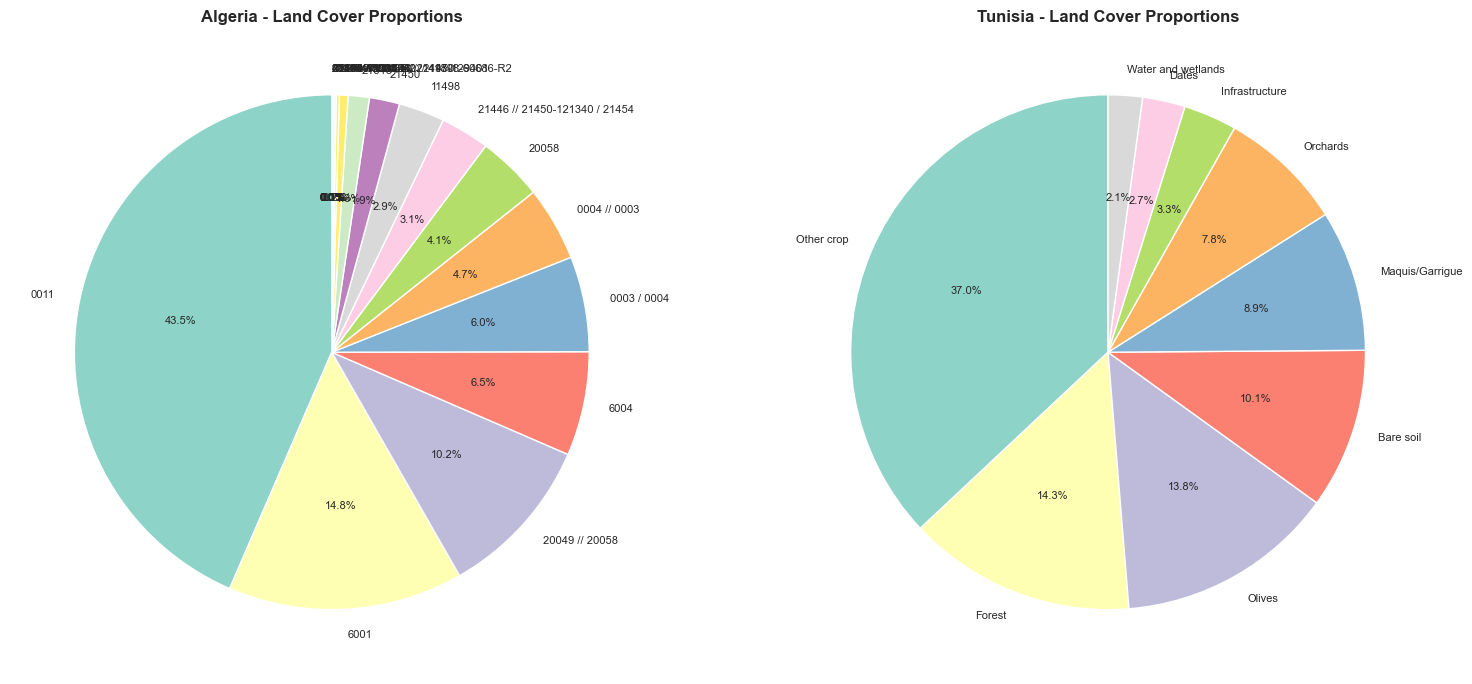


✓ Pie charts generated!


In [7]:
# Pie charts for land cover proportions
print("="*70)
print("LAND COVER PROPORTIONS - PIE CHARTS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Algeria pie chart
ax1 = axes[0]
algeria_proportions = algeria_lc['landcover'].value_counts()
colors1 = plt.cm.Set3(range(len(algeria_proportions)))
wedges1, texts1, autotexts1 = ax1.pie(algeria_proportions.values, 
                                       labels=algeria_proportions.index,
                                       autopct='%1.1f%%',
                                       colors=colors1,
                                       startangle=90)
ax1.set_title('Algeria - Land Cover Proportions', fontsize=12, fontweight='bold')
plt.setp(autotexts1, size=8)
plt.setp(texts1, size=8)

# Tunisia pie chart
ax2 = axes[1]
tunisia_proportions = tunisia_lc['landcover'].value_counts()
colors2 = plt.cm.Set3(range(len(tunisia_proportions)))
wedges2, texts2, autotexts2 = ax2.pie(tunisia_proportions.values, 
                                       labels=tunisia_proportions.index,
                                       autopct='%1.1f%%',
                                       colors=colors2,
                                       startangle=90)
ax2.set_title('Tunisia - Land Cover Proportions', fontsize=12, fontweight='bold')
plt.setp(autotexts2, size=8)
plt.setp(texts2, size=8)

plt.tight_layout()
plt.show()

print("\n✓ Pie charts generated!")
print("="*70)

### 2.2 Bivariate Analysis

BIVARIATE ANALYSIS - GEOGRAPHIC DISTRIBUTION BY LAND COVER

--- Extracting centroid coordinates for analysis ---


C:\Users\mehdi\AppData\Local\Temp\ipykernel_4724\866526784.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  algeria_lc['centroid_x'] = algeria_lc.geometry.centroid.x
C:\Users\mehdi\AppData\Local\Temp\ipykernel_4724\866526784.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  algeria_lc['centroid_y'] = algeria_lc.geometry.centroid.y
C:\Users\mehdi\AppData\Local\Temp\ipykernel_4724\866526784.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tunisia_lc['centroid_x'] = tunisia_lc.geometry.centroid.x
C:\Users\mehdi\AppData\Local\Temp\ipykernel_4724\866526784.py:13: Us

Algeria centroids extracted: 386454 polygons
Tunisia centroids extracted: 4747 polygons


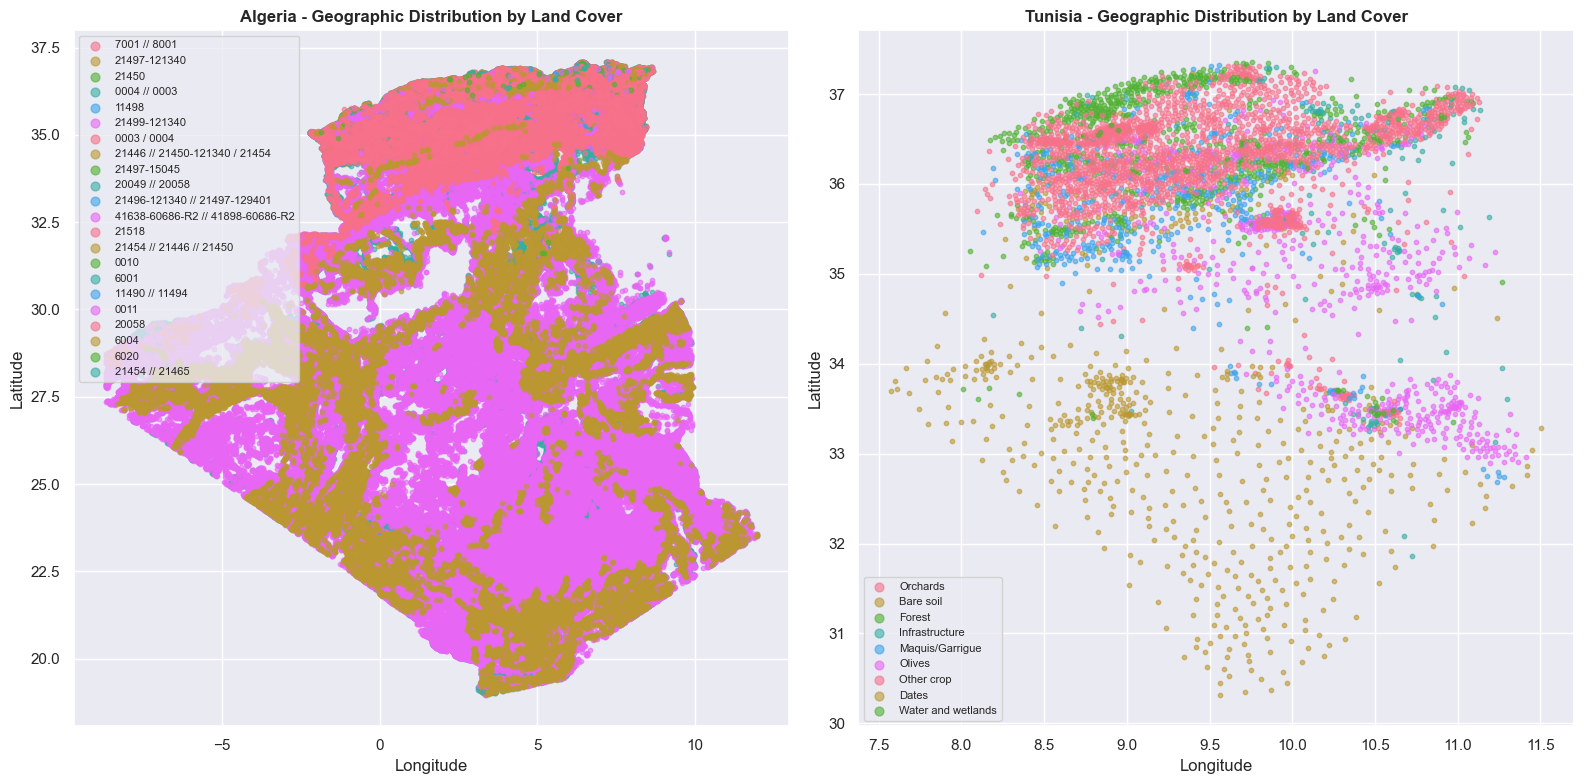


✓ Geographic distribution analysis complete!


In [7]:
print("="*70)
print("BIVARIATE ANALYSIS - GEOGRAPHIC DISTRIBUTION BY LAND COVER")
print("="*70)

# Extract coordinates from geometry for bivariate analysis
print("\n--- Extracting centroid coordinates for analysis ---")

# Both datasets now have polygons, so we extract centroids
algeria_lc['centroid_x'] = algeria_lc.geometry.centroid.x
algeria_lc['centroid_y'] = algeria_lc.geometry.centroid.y

tunisia_lc['centroid_x'] = tunisia_lc.geometry.centroid.x
tunisia_lc['centroid_y'] = tunisia_lc.geometry.centroid.y

print(f"Algeria centroids extracted: {len(algeria_lc)} polygons")
print(f"Tunisia centroids extracted: {len(tunisia_lc)} polygons")

# Scatter plot: Geographic distribution by land cover type
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Algeria scatter plot
ax1 = axes[0]
for lc_type in algeria_lc['landcover'].unique():
    subset = algeria_lc[algeria_lc['landcover'] == lc_type]
    ax1.scatter(subset['centroid_x'], subset['centroid_y'], 
                label=lc_type, alpha=0.6, s=10)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Algeria - Geographic Distribution by Land Cover', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=8, markerscale=2)

# Tunisia scatter plot
ax2 = axes[1]
for lc_type in tunisia_lc['landcover'].unique():
    subset = tunisia_lc[tunisia_lc['landcover'] == lc_type]
    ax2.scatter(subset['centroid_x'], subset['centroid_y'], 
                label=lc_type, alpha=0.6, s=10)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Tunisia - Geographic Distribution by Land Cover', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

print("\n✓ Geographic distribution analysis complete!")
print("="*70)

---
## Section 3: Data Preprocessing

In [8]:
print("="*70)
print("DATA PREPROCESSING")
print("="*70)

# =====================================================
# 3.1 Check for Missing Values
# =====================================================
print("\n--- 3.1 Missing Values Analysis ---")

print("\nAlgeria Dataset - Missing Values:")
algeria_missing = algeria_lc.isnull().sum()
print(algeria_missing[algeria_missing > 0] if algeria_missing.sum() > 0 else "  No missing values")

print("\nTunisia Dataset - Missing Values:")
tunisia_missing = tunisia_lc.isnull().sum()
print(tunisia_missing[tunisia_missing > 0] if tunisia_missing.sum() > 0 else "  No missing values")

# =====================================================
# 3.2 Check for Duplicates
# =====================================================
print("\n--- 3.2 Duplicate Analysis ---")

# Check for duplicate geometries (based on centroid coordinates)
algeria_duplicates = algeria_lc.duplicated(subset=['centroid_x', 'centroid_y']).sum()
tunisia_duplicates = tunisia_lc.duplicated(subset=['centroid_x', 'centroid_y']).sum()

print(f"\nAlgeria - Duplicate geometries: {algeria_duplicates} ({algeria_duplicates/len(algeria_lc)*100:.2f}%)")
print(f"Tunisia - Duplicate geometries: {tunisia_duplicates} ({tunisia_duplicates/len(tunisia_lc)*100:.2f}%)")

# Remove duplicates if any
if algeria_duplicates > 0:
    algeria_lc_clean = algeria_lc.drop_duplicates(subset=['centroid_x', 'centroid_y'], keep='first')
    print(f"  Algeria: Removed {algeria_duplicates} duplicates → {len(algeria_lc_clean)} records remaining")
else:
    algeria_lc_clean = algeria_lc.copy()
    print(f"  Algeria: No duplicates to remove")

if tunisia_duplicates > 0:
    tunisia_lc_clean = tunisia_lc.drop_duplicates(subset=['centroid_x', 'centroid_y'], keep='first')
    print(f"  Tunisia: Removed {tunisia_duplicates} duplicates → {len(tunisia_lc_clean)} records remaining")
else:
    tunisia_lc_clean = tunisia_lc.copy()
    print(f"  Tunisia: No duplicates to remove")

# =====================================================
# 3.3 Validate Geometry
# =====================================================
print("\n--- 3.3 Geometry Validation ---")

algeria_invalid = (~algeria_lc_clean.geometry.is_valid).sum()
tunisia_invalid = (~tunisia_lc_clean.geometry.is_valid).sum()

print(f"Algeria - Invalid geometries: {algeria_invalid}")
print(f"Tunisia - Invalid geometries: {tunisia_invalid}")

if algeria_invalid > 0:
    algeria_lc_clean['geometry'] = algeria_lc_clean.geometry.buffer(0)
    print(f"  Algeria: Fixed {algeria_invalid} invalid geometries using buffer(0)")

if tunisia_invalid > 0:
    tunisia_lc_clean['geometry'] = tunisia_lc_clean.geometry.buffer(0)
    print(f"  Tunisia: Fixed {tunisia_invalid} invalid geometries using buffer(0)")

print("\n" + "="*70)
print("PREPROCESSING SUMMARY")
print("="*70)
print(f"\nAlgeria: {len(algeria_lc)} → {len(algeria_lc_clean)} records")
print(f"Tunisia: {len(tunisia_lc)} → {len(tunisia_lc_clean)} records")
print(f"\nBoth datasets now have polygon geometries:")
print(f"  Algeria: {algeria_lc_clean.geom_type.unique().tolist()}")
print(f"  Tunisia: {tunisia_lc_clean.geom_type.unique().tolist()}")
print("\n✓ Data preprocessing complete!")
print("="*70)

DATA PREPROCESSING

--- 3.1 Missing Values Analysis ---

Algeria Dataset - Missing Values:
  No missing values

Tunisia Dataset - Missing Values:
  No missing values

--- 3.2 Duplicate Analysis ---

Algeria - Duplicate geometries: 0 (0.00%)
Tunisia - Duplicate geometries: 8 (0.17%)
  Algeria: No duplicates to remove
  Tunisia: Removed 8 duplicates → 4739 records remaining

--- 3.3 Geometry Validation ---
Algeria - Invalid geometries: 7596
Tunisia - Invalid geometries: 0
  Algeria: Fixed 7596 invalid geometries using buffer(0)

PREPROCESSING SUMMARY

Algeria: 386454 → 386454 records
Tunisia: 4747 → 4739 records

Both datasets now have polygon geometries:
  Algeria: ['Polygon']
  Tunisia: ['Polygon']

✓ Data preprocessing complete!


---
## Section 4: Geographic Visualization

### 4.1 Land Cover Maps (Both as Polygons)

In [1]:
print("="*70)
print("GEOGRAPHIC VISUALIZATION - ALGERIA LAND COVER MAP")
print("="*70)

# Create a comprehensive map for Algeria
fig, ax = plt.subplots(figsize=(7, 6))

# Plot Algeria land cover with legend
algeria_lc_clean.plot(column='landcover', 
                      ax=ax, 
                      legend=True, 
                      legend_kwds={'title': 'Land Cover Type', 'loc': 'lower left', 'fontsize': 9},
                      cmap='Set3',
                      edgecolor='black',
                      linewidth=0.1,
                      alpha=0.8)

ax.set_title('Algeria - Land Cover Distribution (Polygons)', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n✓ Algeria land cover map generated!")
print("="*70)

GEOGRAPHIC VISUALIZATION - ALGERIA LAND COVER MAP


NameError: name 'plt' is not defined

GEOGRAPHIC VISUALIZATION - TUNISIA LAND COVER MAP (VORONOI POLYGONS)


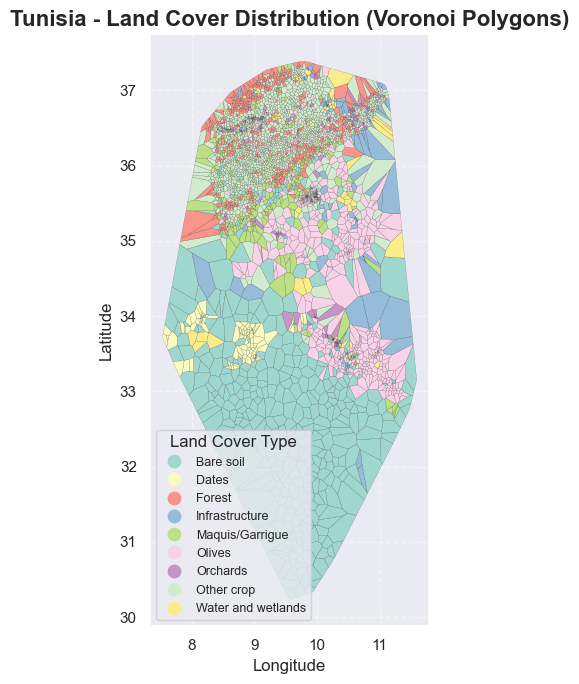


✓ Tunisia land cover map generated with Voronoi polygon representation!


In [9]:
print("="*70)
print("GEOGRAPHIC VISUALIZATION - TUNISIA LAND COVER MAP (VORONOI POLYGONS)")
print("="*70)

# Create a comprehensive map for Tunisia (now with Voronoi polygons)
fig, ax = plt.subplots(figsize=(6, 7))

# Plot Tunisia land cover with polygon styling (like Algeria)
tunisia_lc_clean.plot(column='landcover', 
                      ax=ax, 
                      legend=True, 
                      legend_kwds={'title': 'Land Cover Type', 'loc': 'lower left', 'fontsize': 9},
                      cmap='Set3',
                      edgecolor='black',
                      linewidth=0.1,
                      alpha=0.8)

ax.set_title('Tunisia - Land Cover Distribution (Voronoi Polygons)', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n✓ Tunisia land cover map generated with Voronoi polygon representation!")
print("="*70)

### 4.2 Combined Map - Algeria & Tunisia (Both Polygons)

COMBINED MAP - ALGERIA & TUNISIA LAND COVER (BOTH POLYGONS)


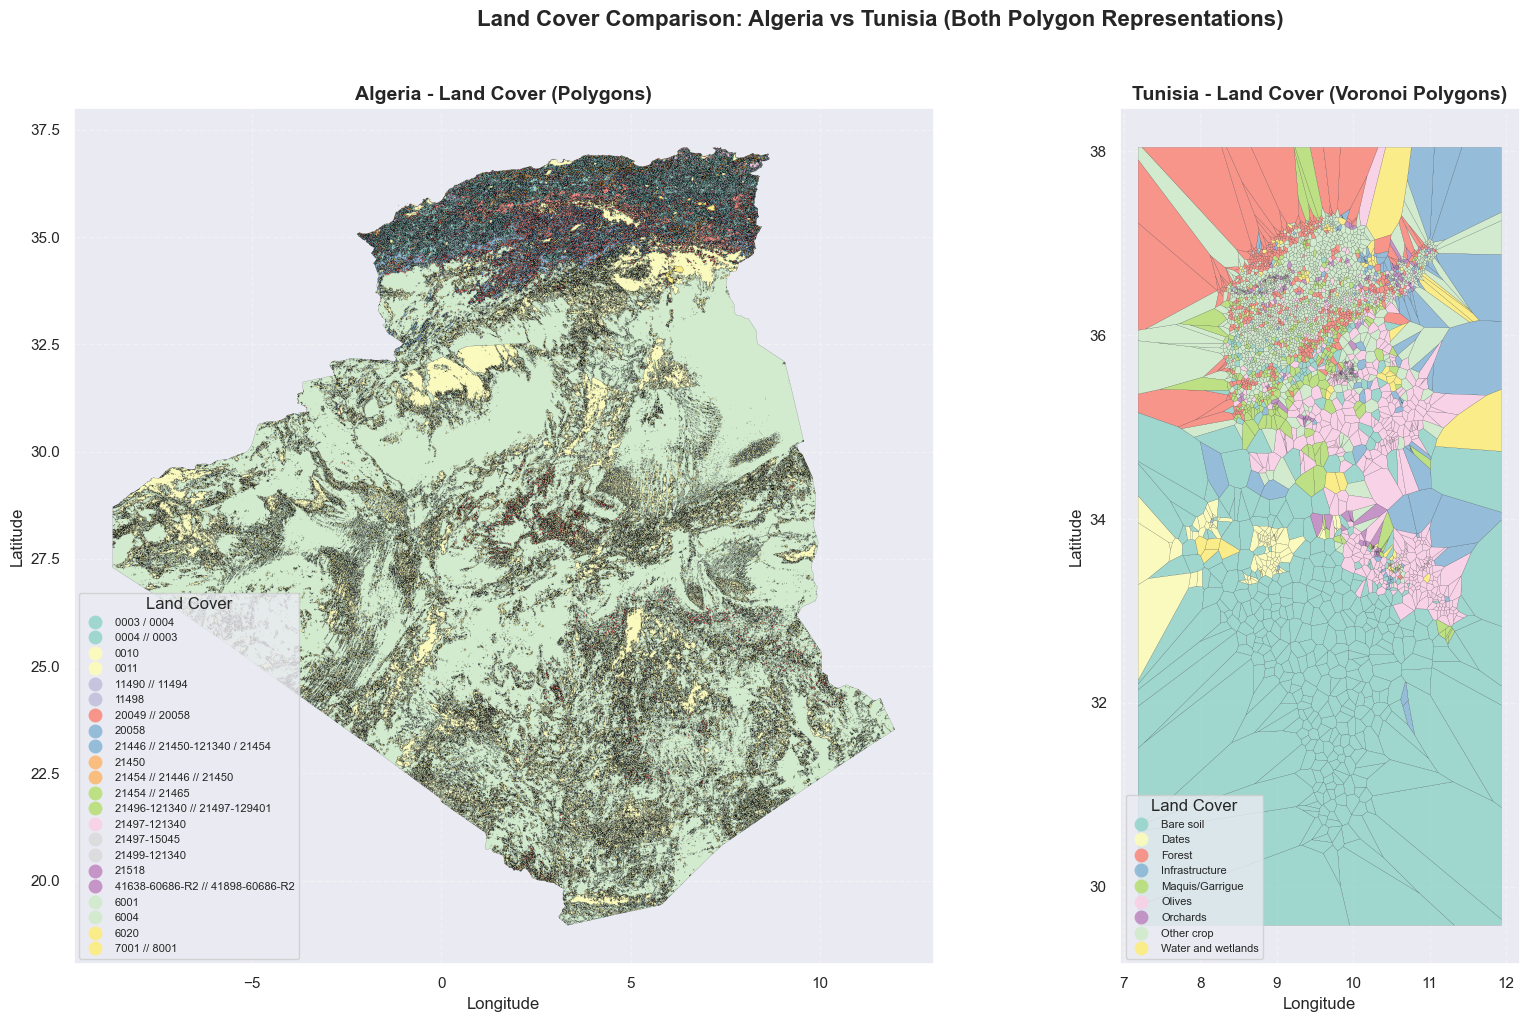


✓ Combined map generated with consistent polygon representations!


In [12]:
print("="*70)
print("COMBINED MAP - ALGERIA & TUNISIA LAND COVER (BOTH POLYGONS)")
print("="*70)

# Create side-by-side comparison (both with polygon styling)
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Algeria
ax1 = axes[0]
algeria_lc_clean.plot(column='landcover', 
                      ax=ax1, 
                      legend=True, 
                      legend_kwds={'title': 'Land Cover', 'loc': 'lower left', 'fontsize': 8},
                      cmap='Set3',
                      edgecolor='black',
                      linewidth=0.1,
                      alpha=0.8)
ax1.set_title('Algeria - Land Cover (Polygons)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, linestyle='--', alpha=0.3)

# Tunisia (now also polygons)
ax2 = axes[1]
tunisia_lc_clean.plot(column='landcover', 
                      ax=ax2, 
                      legend=True, 
                      legend_kwds={'title': 'Land Cover', 'loc': 'lower left', 'fontsize': 8},
                      cmap='Set3',
                      edgecolor='black',
                      linewidth=0.1,
                      alpha=0.8)
ax2.set_title('Tunisia - Land Cover (Voronoi Polygons)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Land Cover Comparison: Algeria vs Tunisia (Both Polygon Representations)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Combined map generated with consistent polygon representations!")
print("="*70)

---
## Section 5: Save Results

In [ ]:
print("="*70)
print("SAVING RESULTS")
print("="*70)

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)

# Save cleaned land cover data (both as polygons)
algeria_output = results_dir / 'algeria_landcover_polygons.geojson'
tunisia_output = results_dir / 'tunisia_landcover_polygons.geojson'

algeria_lc_clean.to_file(algeria_output, driver='GeoJSON')
tunisia_lc_clean.to_file(tunisia_output, driver='GeoJSON')

print(f"\n✓ Saved Algeria land cover: {algeria_output}")
print(f"  Records: {len(algeria_lc_clean):,}")
print(f"  Land cover types: {algeria_lc_clean['landcover'].nunique()}")
print(f"  Geometry type: {algeria_lc_clean.geom_type.unique().tolist()}")

print(f"\n✓ Saved Tunisia land cover: {tunisia_output}")
print(f"  Records: {len(tunisia_lc_clean):,}")
print(f"  Land cover types: {tunisia_lc_clean['landcover'].nunique()}")
print(f"  Geometry type: {tunisia_lc_clean.geom_type.unique().tolist()}")

# Summary
print("\n" + "="*70)
print("ANALYSIS COMPLETE - SUMMARY")
print("="*70)
print(f"\nAlgeria Land Cover Dataset:")
print(f"  • Total records: {len(algeria_lc_clean):,}")
print(f"  • Land cover types: {algeria_lc_clean['landcover'].nunique()}")
print(f"  • Geometry type: Polygon (original)")
print(f"  • CRS: {algeria_lc_clean.crs}")

print(f"\nTunisia Land Cover Dataset:")
print(f"  • Total records: {len(tunisia_lc_clean):,}")
print(f"  • Land cover types: {tunisia_lc_clean['landcover'].nunique()}")
print(f"  • Geometry type: Polygon (converted from points via Voronoi)")
print(f"  • CRS: {tunisia_lc_clean.crs}")

print(f"\nOutput Files:")
print(f"  • {algeria_output.name}")
print(f"  • {tunisia_output.name}")

print("\n" + "="*70)
print("✓ ALL PROCESSING COMPLETE!")
print("="*70)